<a href="https://colab.research.google.com/github/DakotaNelson09/DSRP-Dakota-Nelson/blob/master/DSRP_Notebook_Dakota_Nelson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.linear_model import LinearRegression
from sklearn import model_selection
from sklearn.metrics import r2_score, mean_absolute_error

In [4]:
#Read Dataset
loans_df = pd.read_csv('/content/lendingclub_loans_export.csv')

In [5]:
#Initial Cleaning

#Change NA values to null
loans_df = loans_df.replace("NA", np.nan)

#Droped join annual income columns (>85% null rate for both)
loans_df.drop(columns = ["annual_income_joint", "verification_income_joint"], inplace = True)

#All loans were 2018, remove year from issue month
loans_df["issue_month"] = pd.to_datetime(loans_df["issue_month"], format="%b-%Y").dt.strftime("%b")

#Grade information included in subgrade
loans_df.drop(columns = ["grade"], inplace = True)

loans_df.to_csv("lendingclub_loans_clean.csv", index = False)

In [6]:
print(loans_df.shape)
print(loans_df.dtypes)
print(loans_df.isnull().sum())
loans_df.head()

(10000, 52)
emp_title                            object
emp_length                          float64
state                                object
homeownership                        object
annual_income                       float64
verified_income                      object
debt_to_income                      float64
debt_to_income_joint                float64
delinq_2y                             int64
months_since_last_delinq            float64
earliest_credit_line                  int64
inquiries_last_12m                    int64
total_credit_lines                    int64
open_credit_lines                     int64
total_credit_limit                    int64
total_credit_utilized                 int64
num_collections_last_12m              int64
num_historical_failed_to_pay          int64
months_since_90d_late               float64
current_accounts_delinq               int64
total_collection_amount_ever          int64
current_installment_accounts          int64
accounts_opened_24m 

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,debt_to_income_joint,delinq_2y,months_since_last_delinq,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,0,38.0,...,C3,Mar,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,0,NaN,...,C1,Feb,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,0,28.0,...,D1,Feb,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,0,NaN,...,A3,Jan,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,37.66,0,NaN,...,C3,Mar,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [7]:
#Corrupted issue_month column
print(loans_df['issue_month'].nunique(), "unique values")
print(loans_df['issue_month'].iloc[0][:100])

3 unique values
Mar


In [8]:
#Check NaN
pd.crosstab(loans_df['application_type'], loans_df['debt_to_income_joint'].isna())


debt_to_income_joint,False,True
application_type,,
individual,0,8505
joint,1495,0


In [9]:
#Check NaN
loans_df['num_accounts_120d_past_due'].value_counts(dropna=False)

,count
num_accounts_120d_past_due,
0.0,9682
NaN,318


In [10]:
#Sanity Check
loans_df[['annual_income', 'loan_amount', 'interest_rate', 'debt_to_income']].describe()

,annual_income,loan_amount,interest_rate,debt_to_income
count,1.000000e+04,10000.000000,10000.000000,9976.000000
mean,7.922215e+04,16361.922500,12.427524,19.308192
std,6.473429e+04,10301.956759,5.001105,15.004851
min,0.000000e+00,1000.000000,5.310000,0.000000
25%,4.500000e+04,8000.000000,9.430000,11.057500
50%,6.500000e+04,14500.000000,11.980000,17.570000
75%,9.500000e+04,24000.000000,15.050000,25.002500
max,2.300000e+06,40000.000000,30.940000,469.090000


In [11]:
#Drop junk column
loans_df = loans_df.drop(columns=['num_accounts_120d_past_due'])

In [12]:
#Polishing
#Letter Grade
loans_df['grade'] = loans_df['sub_grade'].str[0]

#Simplified loan status + trouble flag
status_map = {'Current': 'Current', 'Fully Paid': 'Fully Paid',
              'In Grace Period': 'Late/Grace', 'Late (16-30 days)': 'Late/Grace',
              'Late (31-120 days)': 'Late/Grace', 'Charged Off': 'Charged Off'}
loans_df['status_simple'] = loans_df['loan_status'].map(status_map)
loans_df['is_troubled'] = loans_df['status_simple'].isin(['Late/Grace', 'Charged Off'])

#Credit history length
loans_df['credit_history_years'] = 2018 - loans_df['earliest_credit_line']

#Credit utilization ratio
loans_df['credit_utilization'] = (loans_df['total_credit_utilized'] /
                            loans_df['total_credit_limit'].replace(0, np.nan)).clip(upper=1.5)

#Ever-delinquent flag (NaN = never delinquent)
loans_df['ever_delinquent'] = loans_df['months_since_last_delinq'].notna()

#Income brackets for grouping
loans_df['income_bracket'] = pd.cut(loans_df['annual_income'],
                              bins=[0, 40000, 70000, 100000, 150000, np.inf],
                              labels=['<40k', '40-70k', '70-100k', '100-150k', '150k+'],
                              include_lowest=True)

#Outlier flags
loans_df['income_outlier'] = loans_df['annual_income'] > 500000
loans_df['dti_outlier'] = loans_df['debt_to_income'] > 100

loans_df.to_csv('lendingclub_clean.csv', index=False)

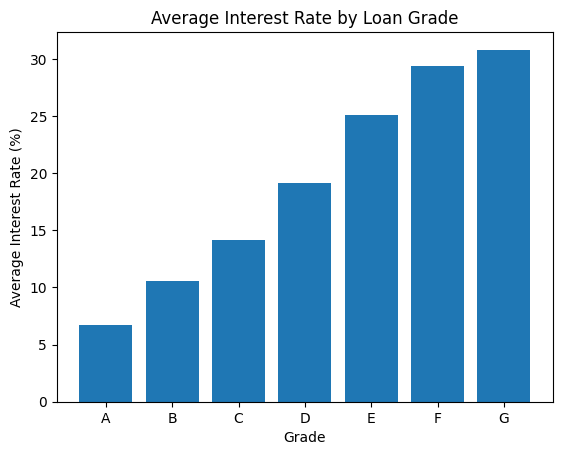

In [13]:
#Grade and Avg Interest
grade_rates = loans_df.groupby('grade')['interest_rate'].mean()

plt.bar(grade_rates.index, grade_rates.values)

plt.title("Average Interest Rate by Loan Grade")
plt.xlabel("Grade")
plt.ylabel("Average Interest Rate (%)")

plt.show()

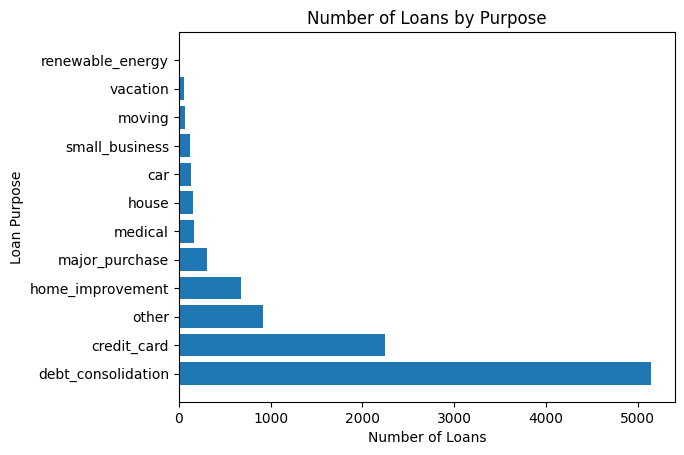

In [14]:
#Loans per Purpose
purpose_counts = loans_df['loan_purpose'].value_counts()

plt.barh(purpose_counts.index, purpose_counts.values)

plt.title("Number of Loans by Purpose")
plt.xlabel("Number of Loans")
plt.ylabel("Loan Purpose")

plt.show()

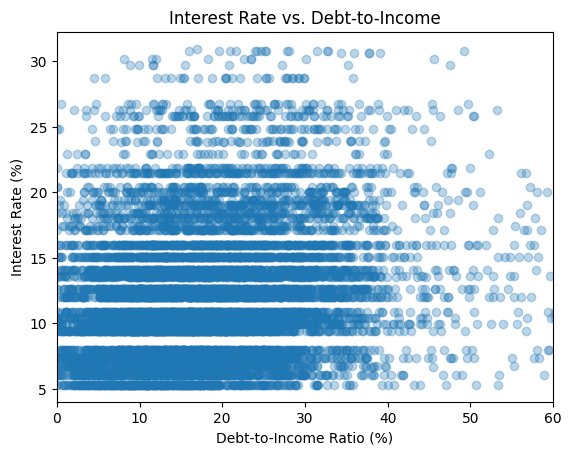

In [15]:
#Interest vs DTI
plt.scatter(loans_df['debt_to_income'], loans_df['interest_rate'], alpha=0.3)

plt.title("Interest Rate vs. Debt-to-Income")
plt.xlabel("Debt-to-Income Ratio (%)")
plt.ylabel("Interest Rate (%)")
plt.xlim(0, 60)

plt.show()

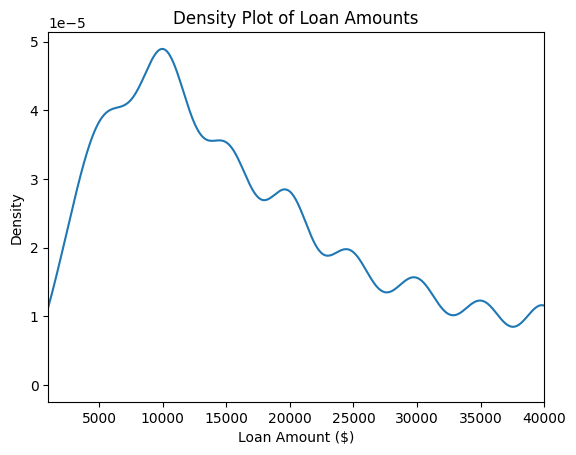

In [16]:
#Distribution of Loan Amounts
loans_df["loan_amount"].plot(kind="density")

plt.title("Density Plot of Loan Amounts")
plt.xlabel("Loan Amount ($)")
plt.xlim(loans_df["loan_amount"].min(), loans_df["loan_amount"].max())

plt.show()

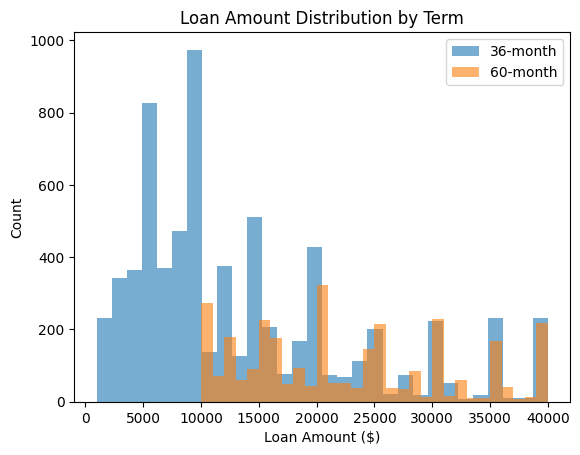

In [17]:
#Loan Amounts by Term
loans_36 = loans_df[loans_df['term'] == 36]['loan_amount']
loans_60 = loans_df[loans_df['term'] == 60]['loan_amount']

plt.hist(loans_36, bins=30, alpha=0.6, label='36-month')
plt.hist(loans_60, bins=30, alpha=0.6, label='60-month')

plt.title("Loan Amount Distribution by Term")
plt.xlabel("Loan Amount ($)")
plt.ylabel("Count")
plt.legend()

plt.show()

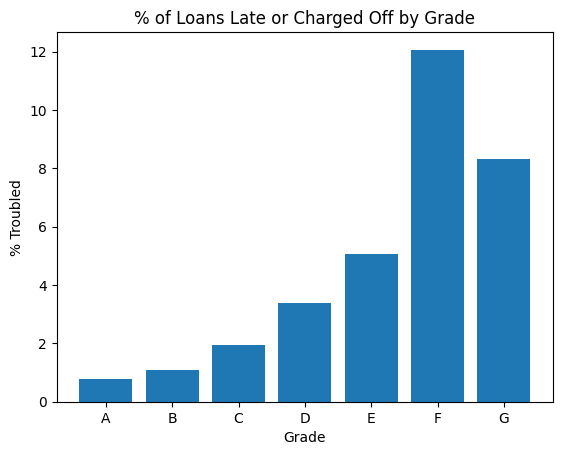

In [18]:
#% Troubled Loans by Grade
trouble_rate = loans_df.groupby('grade')['is_troubled'].mean() * 100

plt.bar(trouble_rate.index, trouble_rate.values)

plt.title("% of Loans Late or Charged Off by Grade")
plt.xlabel("Grade")
plt.ylabel("% Troubled")

plt.show()

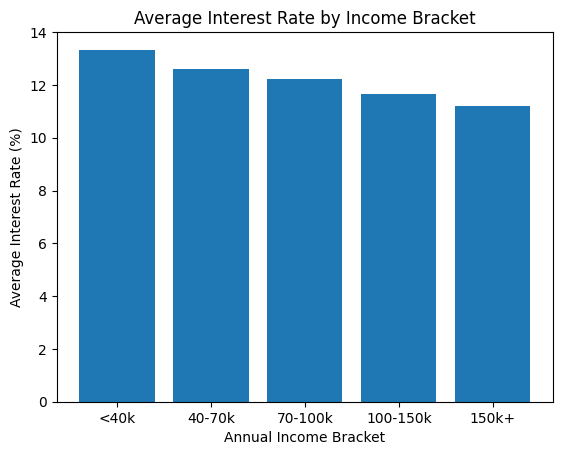

In [19]:
#Avg Interest Rate by Income Bracket
order = ['<40k', '40-70k', '70-100k', '100-150k', '150k+']
income_rates = loans_df.groupby('income_bracket')['interest_rate'].mean().reindex(order)

plt.bar(income_rates.index, income_rates.values)

plt.title("Average Interest Rate by Income Bracket")
plt.xlabel("Annual Income Bracket")
plt.ylabel("Average Interest Rate (%)")

plt.show()

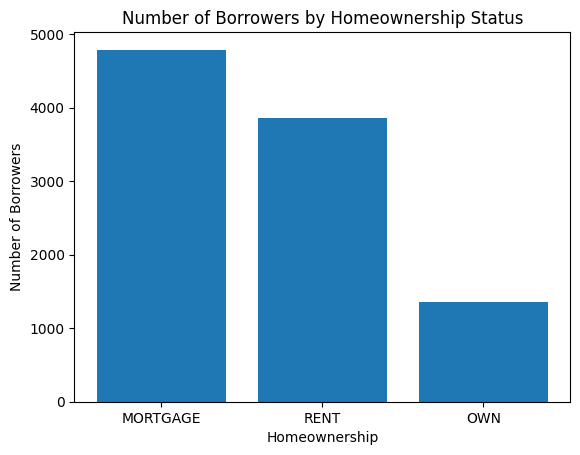

In [20]:
#Homeownership Breakdown
home_counts = loans_df['homeownership'].value_counts()

plt.bar(home_counts.index, home_counts.values)

plt.title("Number of Borrowers by Homeownership Status")
plt.xlabel("Homeownership")
plt.ylabel("Number of Borrowers")

plt.show()

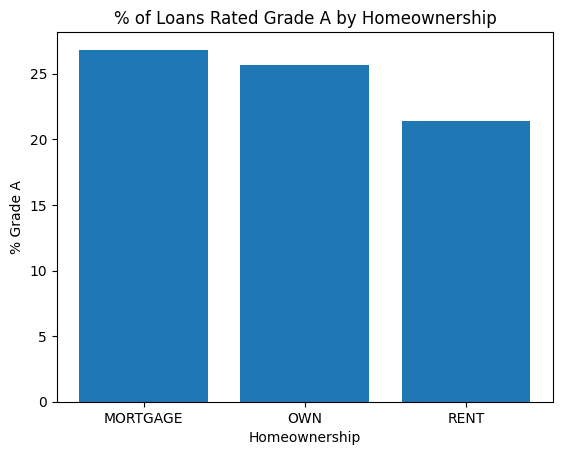

In [21]:
#Fraction of each Ownership type with an A
a_frac = (loans_df['grade'] == 'A').groupby(loans_df['homeownership']).mean() * 100

plt.bar(a_frac.index, a_frac.values)

plt.title("% of Loans Rated Grade A by Homeownership")
plt.xlabel("Homeownership")
plt.ylabel("% Grade A")

plt.show()

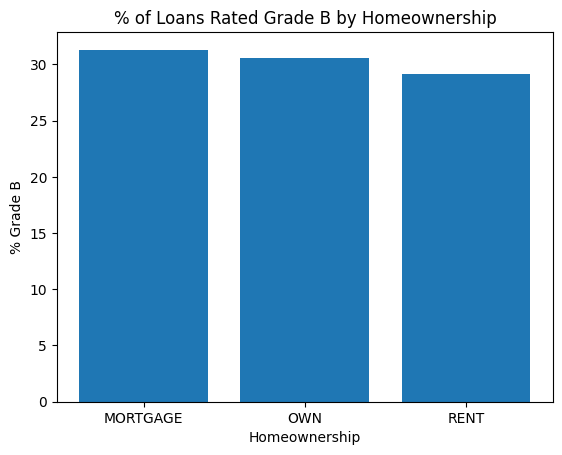

In [22]:
#Fraction of each Ownership type with a B
b_frac = (loans_df['grade'] == 'B').groupby(loans_df['homeownership']).mean() * 100

plt.bar(b_frac.index, b_frac.values)

plt.title("% of Loans Rated Grade B by Homeownership")
plt.xlabel("Homeownership")
plt.ylabel("% Grade B")

plt.show()

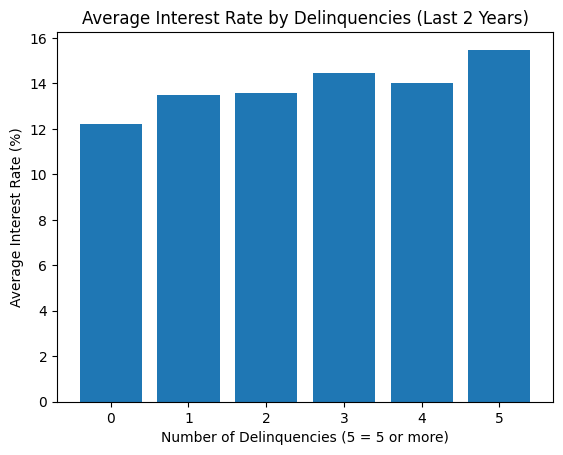

In [23]:
#Interest Rate by num Delinquencies
loans_df['delinq_capped'] = loans_df['delinq_2y'].clip(upper=5)
delinq_rates = loans_df.groupby('delinq_capped')['interest_rate'].mean()

plt.bar(delinq_rates.index, delinq_rates.values)

plt.title("Average Interest Rate by Delinquencies (Last 2 Years)")
plt.xlabel("Number of Delinquencies (5 = 5 or more)")
plt.ylabel("Average Interest Rate (%)")

plt.show()

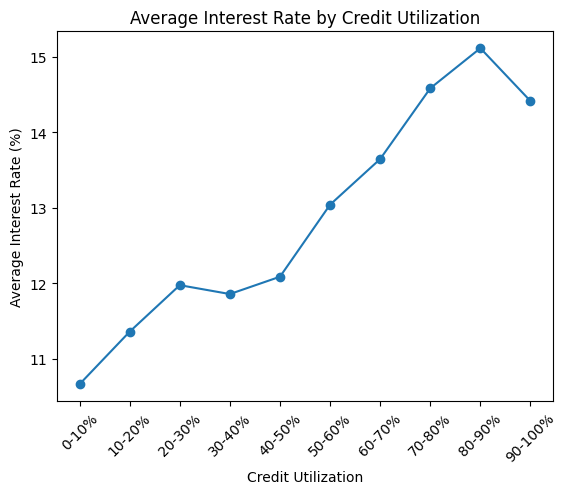

In [24]:
#Interest Rate vs Credit Utilization

# Bin utilization into 10% chunks
bins = np.arange(0, 1.1, 0.1)
labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%',
          '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']

loans_df['util_bin'] = pd.cut(loans_df['credit_utilization'], bins=bins, labels=labels)

# Group by bin, avg interest
util_rates = loans_df.groupby('util_bin')['interest_rate'].mean()

plt.plot(util_rates.index, util_rates.values, marker='o')

plt.title("Average Interest Rate by Credit Utilization")
plt.xlabel("Credit Utilization")
plt.ylabel("Average Interest Rate (%)")
plt.xticks(rotation=45)

plt.show()

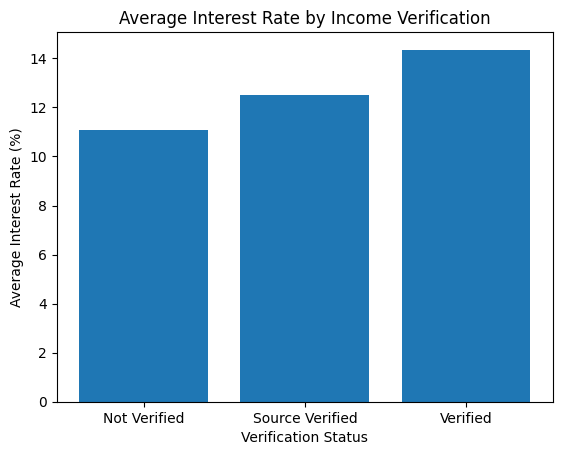

In [25]:
#Avg Interest by Verification Status
ver_rates_interest = loans_df.groupby('verified_income')['interest_rate'].mean()

plt.bar(ver_rates_interest.index, ver_rates_interest.values)

plt.title("Average Interest Rate by Income Verification")
plt.xlabel("Verification Status")
plt.ylabel("Average Interest Rate (%)")

plt.show()

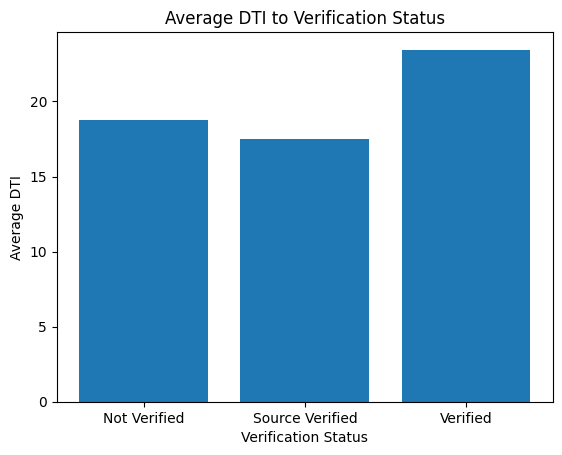

In [26]:
#DTI vs Verification Status
ver_rates_DTI = loans_df.groupby('verified_income')['debt_to_income'].mean()

plt.bar(ver_rates_DTI.index, ver_rates_DTI.values)

plt.title("Average DTI to Verification Status")
plt.xlabel("Verification Status")
plt.ylabel("Average DTI")

plt.show()

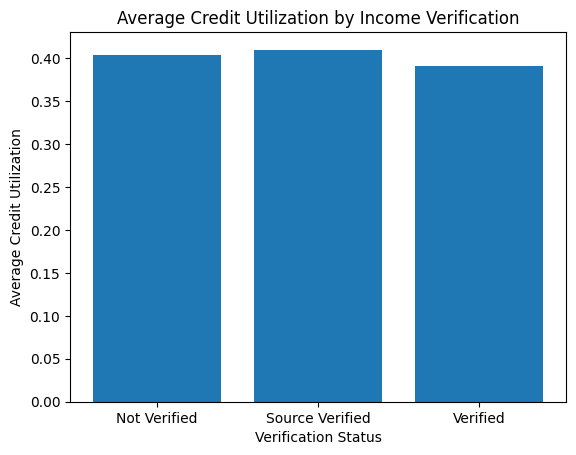

In [27]:
#Avg Credit Utilization to Verification Status
ver_rates_CU = loans_df.groupby('verified_income')['credit_utilization'].mean()

plt.bar(ver_rates_CU.index, ver_rates_CU.values)

plt.title("Average Credit Utilization by Income Verification")
plt.xlabel("Verification Status")
plt.ylabel("Average Credit Utilization")

plt.show()

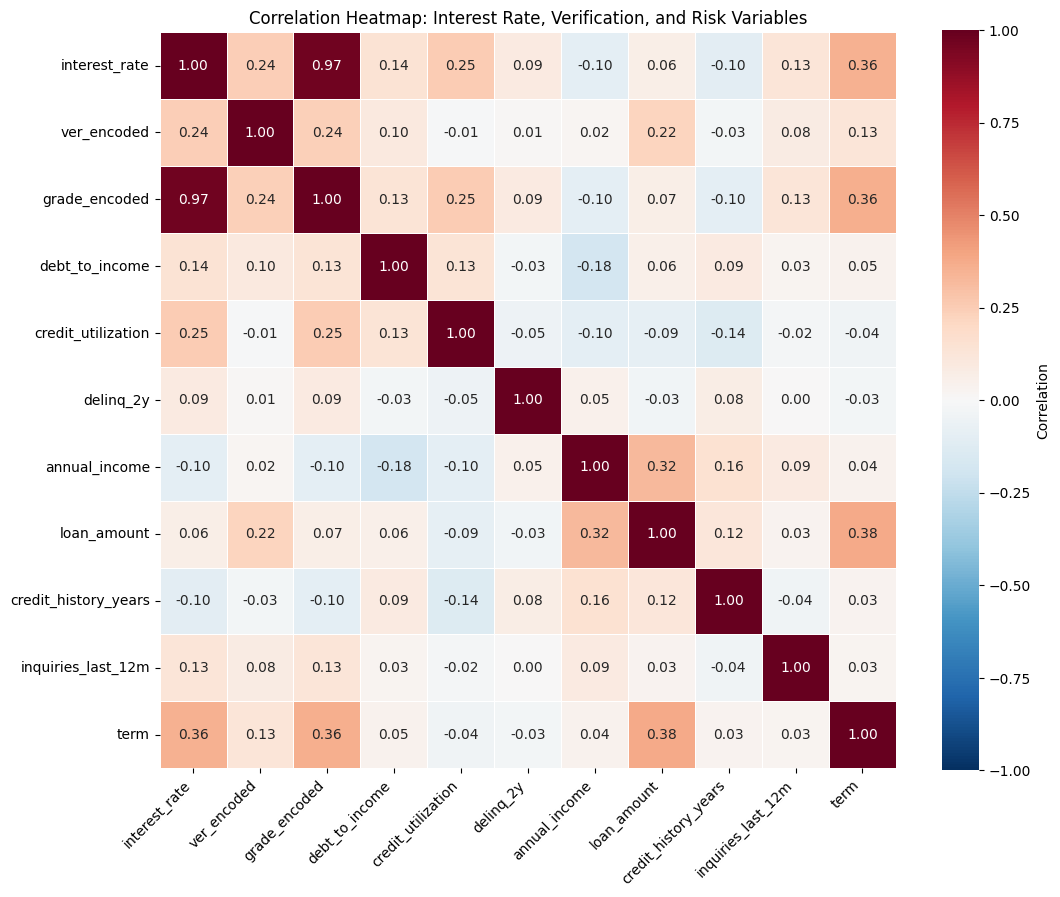

In [28]:
#Correlation Heatmap

# Encode categorical variables numerically so they can be correlated
# verified_income is ordinal: more verification = higher number
ver_map = {'Not Verified': 0, 'Source Verified': 1, 'Verified': 2}
loans_df['ver_encoded'] = loans_df['verified_income'].map(ver_map)

# grade is ordinal too: A (best) = 1 through G (worst) = 7
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
loans_df['grade_encoded'] = loans_df['grade'].map(grade_map)

corr_cols = ['interest_rate', 'ver_encoded', 'grade_encoded',
             'debt_to_income', 'credit_utilization', 'delinq_2y',
             'annual_income', 'loan_amount', 'credit_history_years',
             'inquiries_last_12m', 'term']

corr_matrix = loans_df[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation'})

plt.title("Correlation Heatmap: Interest Rate, Verification, and Risk Variables")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [29]:
#ANOVA - is the rate gap across verification levels real?
#H0: mean interest rate is the same across all three levels
#Ha: at least one level differs

groups = loans_df.groupby('verified_income')['interest_rate']
not_ver = groups.get_group('Not Verified')
source_ver = groups.get_group('Source Verified')
verified = groups.get_group('Verified')

f_stat, p_val = stats.f_oneway(not_ver, source_ver, verified)
print("ANOVA F =", f_stat, "p =", p_val)

tukey = pairwise_tukeyhsd(endog=loans_df['interest_rate'],
                          groups=loans_df['verified_income'], alpha=0.05)
print(tukey)

ANOVA F = 315.94097218616315 p = 8.922173289826357e-134
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
     group1          group2     meandiff p-adj lower  upper  reject
-------------------------------------------------------------------
   Not Verified Source Verified    1.416   0.0 1.1564 1.6756   True
   Not Verified        Verified   3.2543   0.0 2.9503 3.5583   True
Source Verified        Verified   1.8383   0.0 1.5418 2.1347   True
-------------------------------------------------------------------


In [30]:
#Selection evidence - were verified borrowers already riskier?
print(loans_df.groupby('verified_income')[
    ['debt_to_income','credit_utilization','loan_amount']].mean())

#H0: mean DTI equal | Ha: Verified DTI > Not Verified
dti_ver = loans_df[loans_df['verified_income']=='Verified']['debt_to_income'].dropna()
dti_not = loans_df[loans_df['verified_income']=='Not Verified']['debt_to_income'].dropna()
result = stats.ttest_ind(dti_ver, dti_not, alternative='greater')
print("DTI t-test p =", result.pvalue)

#H0: mean loan amount equal | Ha: Verified > Not Verified
amt_ver = loans_df[loans_df['verified_income']=='Verified']['loan_amount']
amt_not = loans_df[loans_df['verified_income']=='Not Verified']['loan_amount']
result = stats.ttest_ind(amt_ver, amt_not, alternative='greater')
print("Loan amount t-test p =", result.pvalue)

#H0: mean utilization equal | Ha: Verified > Not Verified
cu_ver = loans_df[loans_df['verified_income']=='Verified']['credit_utilization'].dropna()
cu_not = loans_df[loans_df['verified_income']=='Not Verified']['credit_utilization'].dropna()
result = stats.ttest_ind(cu_ver, cu_not, alternative='greater')
print("Credit utilization t-test p =", result.pvalue)

                 debt_to_income  credit_utilization   loan_amount
verified_income                                                  
Not Verified          18.755626            0.403256  13521.967168
Source Verified       17.486911            0.409835  17137.275267
Verified              23.446691            0.390710  19425.436681
DTI t-test p = 3.645978958438678e-28
Loan amount t-test p = 7.528774002809919e-111
Credit utilization t-test p = 0.9623686184368416


In [31]:
#Regression - Model A (verification alone)
features_a = loans_df[['ver_encoded']].dropna()
label_a = loans_df.loc[features_a.index, 'interest_rate']

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    features_a, label_a, test_size=0.2, random_state=42)

model_a = LinearRegression()
model_a.fit(X_train, y_train)
pred_a = model_a.predict(X_test)

print("Model A ver coefficient:", model_a.coef_[0])
print("Model A R2:", r2_score(y_test, pred_a))

Model A ver coefficient: 1.5959666942220665
Model A R2: 0.05745874674614193


In [32]:
#Model B (verification + observable risk controls)
control_cols = ['ver_encoded','debt_to_income','credit_utilization','delinq_2y',
                'loan_amount','annual_income','credit_history_years','term',
                'inquiries_last_12m']

features_b = loans_df[control_cols].dropna()
label_b = loans_df.loc[features_b.index, 'interest_rate']

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    features_b, label_b, test_size=0.2, random_state=42)

model_b = LinearRegression()
model_b.fit(X_train, y_train)
pred_b = model_b.predict(X_test)

coefficients = pd.DataFrame([model_b.coef_], columns=control_cols)
print(coefficients)
print("Model B R2:", r2_score(y_test, pred_b))
print("Ver coefficient shrinkage:",
      round((1 - model_b.coef_[0]/model_a.coef_[0])*100, 1), "%")

   ver_encoded  debt_to_income  credit_utilization  delinq_2y  loan_amount  \
0     1.330372        0.023178            4.548851   0.889348    -0.000037   

   annual_income  credit_history_years      term  inquiries_last_12m  
0      -0.000005              -0.04412  0.167452            0.241272  
Model B R2: 0.2905458879734104
Ver coefficient shrinkage: 16.6 %


Model C ver coefficient: 0.0942333466943035
Model C R2: 0.9454822288428414


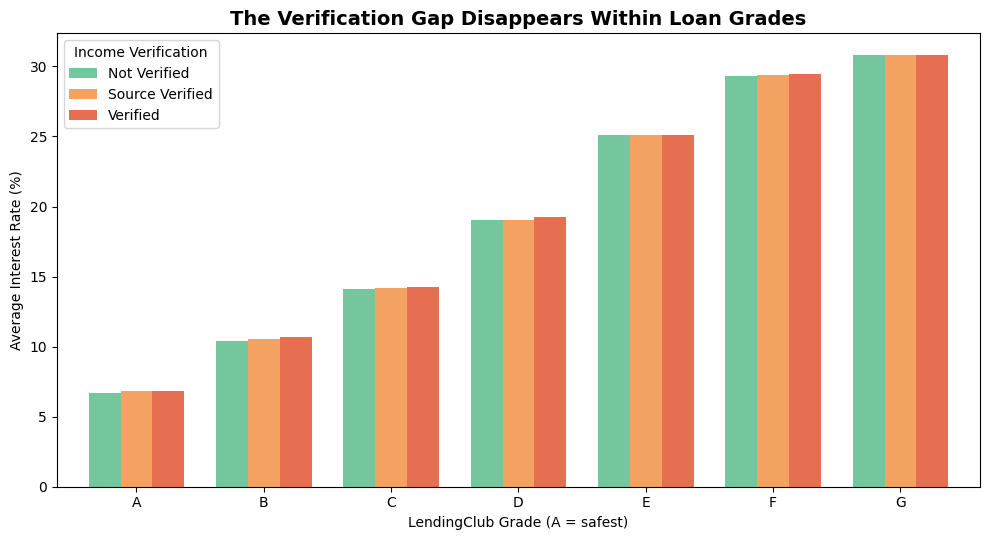

Grade A - gap: 0.19 pts, p = 1.361518973734085e-05
Grade B - gap: 0.24 pts, p = 1.242945411721603e-07
Grade C - gap: 0.15 pts, p = 0.03961642714858092


In [33]:
#Model C (verification + grade) and within-grade comparison
features_c = loans_df[['ver_encoded','grade_encoded']].dropna()
label_c = loans_df.loc[features_c.index, 'interest_rate']

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    features_c, label_c, test_size=0.2, random_state=42)

model_c = LinearRegression()
model_c.fit(X_train, y_train)

print("Model C ver coefficient:", model_c.coef_[0])
print("Model C R2:", r2_score(y_test, model_c.predict(X_test)))

#Rate by grade and verification (table + grouped bar chart)
within = loans_df.groupby(['grade','verified_income'])['interest_rate'].mean().unstack()
within = within[['Not Verified', 'Source Verified', 'Verified']]  # logical order

within.plot(kind='bar', figsize=(10, 5.5),
            color=['#74c69d', '#f4a261', '#e76f51'], width=0.75)

plt.title("The Verification Gap Disappears Within Loan Grades",
          fontsize=14, fontweight='bold')
plt.xlabel("LendingClub Grade (A = safest)")
plt.ylabel("Average Interest Rate (%)")
plt.legend(title="Income Verification")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#ANOVA within each major grade
for g in ['A', 'B', 'C']:
    sub = loans_df[loans_df['grade'] == g]
    gg = sub.groupby('verified_income')['interest_rate']
    f, p = stats.f_oneway(gg.get_group('Not Verified'),
                          gg.get_group('Source Verified'),
                          gg.get_group('Verified'))
    print("Grade", g, "- gap:", round(gg.mean().max() - gg.mean().min(), 2),
          "pts, p =", p)

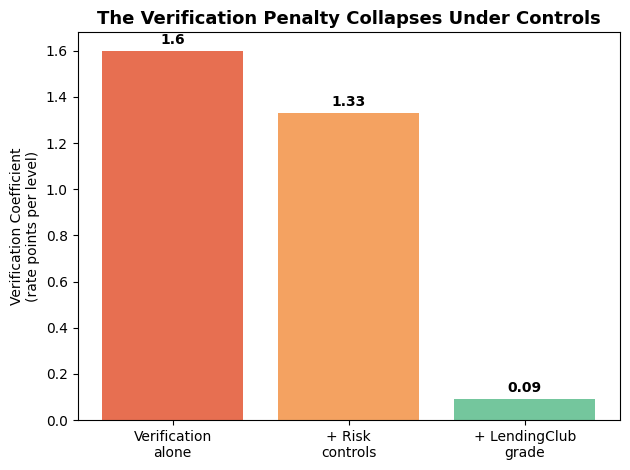

In [34]:
models = ['Verification\nalone', '+ Risk\ncontrols', '+ LendingClub\ngrade']
coefs = [1.60, 1.33, 0.09]

bars = plt.bar(models, coefs, color=['#e76f51', '#f4a261', '#74c69d'])
plt.title('The Verification Penalty Collapses Under Controls',
          fontsize=13, fontweight='bold')
plt.ylabel("Verification Coefficient\n(rate points per level)")
for bar, c in zip(bars, coefs):
    plt.text(bar.get_x() + bar.get_width()/2, c + 0.03, str(c),
             ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
#Create a table to compare regression models
model_specs = {
    'A: Verification only': ['ver_encoded'],
    'B: + Risk controls': ['ver_encoded','debt_to_income','credit_utilization',
                           'delinq_2y','loan_amount','annual_income',
                           'credit_history_years','term','inquiries_last_12m'],
    'C: + Grade': ['ver_encoded','grade_encoded']
}

results = []

for name, cols in model_specs.items():
    features = loans_df[cols].dropna()
    label = loans_df.loc[features.index, 'interest_rate']

    X_train, X_test, y_train, y_test = model_selection.train_test_split(
        features, label, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append({
        'model': name,
        'ver_coefficient': round(model.coef_[0], 3),
        'r2': round(r2_score(y_test, preds), 3),
        'mae': round(mean_absolute_error(y_test, preds), 3)
    })

results_df = pd.DataFrame(results)
print(results_df)

                  model  ver_coefficient     r2    mae
0  A: Verification only            1.596  0.057  3.942
1    B: + Risk controls            1.330  0.291  3.374
2            C: + Grade            0.094  0.945  0.995


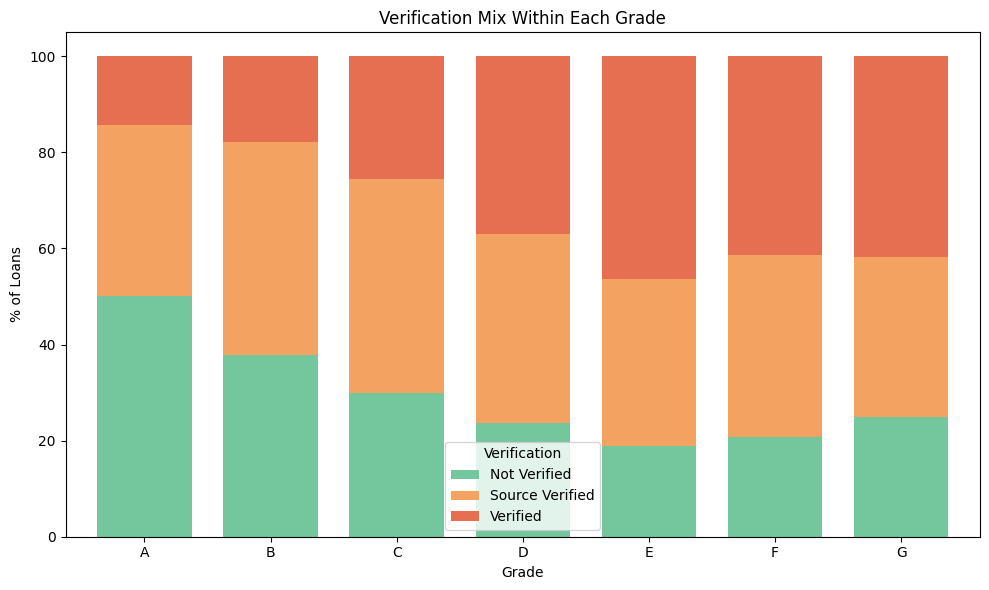

In [36]:
#Verification mix within each grade
pct = loans_df.groupby(['grade','verified_income']).size().unstack()
pct = pct[['Not Verified', 'Source Verified', 'Verified']]
pct = pct.div(pct.sum(axis=1), axis=0) * 100   # normalize each row to 100%

pct.plot(kind='bar', stacked=True, figsize=(10, 6),
         color=['#74c69d', '#f4a261', '#e76f51'], width=0.75)

plt.title("Verification Mix Within Each Grade")
plt.xlabel("Grade")
plt.ylabel("% of Loans")
plt.legend(title="Verification")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()